# 01 — EDA: Deutsche Bahn departures (Phase 1)

**Goal:** understand the HF history + live API well enough to freeze the label, silver schema v1
and the station list. Exploration only — reusable logic lives in `src/dbdelay/`.

**Data:** HF `piebro/deutsche-bahn-data`, `monthly_processed_data/data-{2025-10, 2026-03, 2026-08}.parquet`
(chosen to cover: the old 131-station scope, the new nationwide scope, both DST switches, the latest month),
plus live Timetables API samples captured 2026-09-25 (`tests/fixtures/`).

**Reproduce:** download the three months (≈ 1.3 GB, git-ignored), then run all cells:
```
uv run hf download piebro/deutsche-bahn-data --repo-type dataset --local-dir data/raw/hf   monthly_processed_data/data-2025-10.parquet monthly_processed_data/data-2026-03.parquet   monthly_processed_data/data-2026-08.parquet
```

## Findings (summary)
1. **Scope changed after 2025-10:** 131 → ~5,300 stations (file size ×6). All 30 selected stations have
   departures on every collected day in all three months (§1, §8).
2. **Label base rate:** at the 30 stations, 22.5–26.3 % of non-cancelled departures are ≥ 6 min late;
   3.6–4.2 % are cancelled. Cancelled rows still carry a delay in HF → `is_late = null` for them (§3).
3. **Delay semantics:** `delay_in_min = departure_change_time − departure_planned_time` exactly; the change time is
   always filled (no update ⇒ planned time ⇒ delay 0, ~37 % of rows are exactly 0). The live ETL must use the
   same rule (§2).
4. **Keys:** HF `id` = live `s@id` = `<trip hash>-<YYMMDDHHmm start>-<stop no.>`, unique. `train_line_ride_id`
   is only the hash and repeats across days (99 k hashes vs 1.27 M rides in 2026-08) → silver
   `ride_id` = `id` minus stop suffix, `stop_index` = suffix (≥ 1). HF `eva` has a leading zero → API form (§2).
5. **Time zone / DST:** timestamps are naive Europe/Berlin. The repeated autumn hour exists (1.39× volume across
   131 stations) and can't be inferred reliably → ambiguous/nonexistent times: `NaT`, drop, count (§6).
6. **Gaps & overlaps:** collection outages (2026-03-16 18–21 h, 2026-08-27/28 mornings) and month files that
   overlap at their edges → partition by planned UTC date, dedupe on `event_id`, flag low-volume hours (§7).
7. **EVA drift:** DB merged Berlin Hbf's upper level (8011160) into 8098160 during 2026 → station list uses
   8098160 with `hf_aliases: [8011160]`. Stuttgart's S-Bahn was temporarily on the main EVA in 2026-08. The ETL
   should report stations whose volume or train-type mix shifts (§8).
8. **Signal exists in timetable features:** train type (ICE 46 % vs S-Bahn 16 %), station (3 %–43 %), hour and
   weekday all shift the late rate. Line (~400 keys) and destination (~850) need rare-level grouping (§4, §5).
9. **Risk thresholds:** Low < 0.20 / Medium 0.20–0.45 / High ≥ 0.45 split a baseline-style lookup into
   47 % / 34 % / 18 % of departures → keep as initial values, revisit on calibrated output (§9).
10. **Live API:** `s@id` matches the HF format; plan ↔ fchg join 19/19 on it; cancellation = `cs="c"` (§10).

## 0. Setup

In [1]:
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
HF_GLOB = (ROOT / "data/raw/hf/monthly_processed_data/*.parquet").as_posix()
LATE_MIN = 6  # label threshold (ADR 0001)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# Chart style: one hue for single series; first three categorical slots for the 3 months.
BLUE, MONTH_COLORS, INK_2 = "#2a78d6", ["#2a78d6", "#eb6834", "#1baf7a"], "#52514e"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#c9c8c2",
        "axes.labelcolor": INK_2,
        "text.color": "#0b0b0b",
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "lines.linewidth": 2,
    }
)

config = yaml.safe_load((ROOT / "configs/stations.yaml").read_text(encoding="utf-8"))
stations = pd.DataFrame([{k: s[k] for k in ("eva", "name", "state")} for s in config["stations"]])
aliases = pd.DataFrame(
    [(a, s["eva"]) for s in config["stations"] for a in s.get("hf_aliases", [])],
    columns=["alias", "eva"],
)

con = duckdb.connect()
con.read_parquet(HF_GLOB, filename=True, union_by_name=True).create_view("hf_files")
con.register("stations_df", stations)
con.register("aliases_df", aliases)
con.sql("""
create or replace view raw as
select *, regexp_extract(filename, 'data-([0-9]{4}-[0-9]{2})', 1) as m from hf_files
""")
# Departures only, EVA in API form (no leading zero), retired EVAs mapped via `hf_aliases`.
con.sql("""
create or replace view dep as
select r.* replace (coalesce(a.eva, ltrim(r.eva, '0')) as eva)
from raw r left join aliases_df a on ltrim(r.eva, '0') = a.alias
where r.departure_planned_time is not null
""")
con.sql("""
create or replace view sel as
select * from dep where eva in (select eva from stations_df)
""")


def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

## 1. Volume and scope per month

In [2]:
q("""
select m, count(*) as rows_all, count(departure_planned_time) as departures,
       count(distinct eva) as evas,
       round(avg((departure_planned_time is null)::int), 3) as arrival_only_share
from raw group by m order by m
""")

,m,rows_all,departures,evas,arrival_only_share
0,2025-10,2018378,1567986,131,0.223
1,2026-03,15240797,14006346,5346,0.081
2,2026-08,14516986,13305252,5260,0.083


The collection scope changed after 2025-10: **131 → ~5,300 stations** (file size ×6).
Rows without a planned departure are arrivals at the end of a ride (terminating trains) → dropped in silver.

## 2. Schema, keys and field semantics

In [3]:
q("describe raw")[["column_name", "column_type"]]

,column_name,column_type
0,station_name,VARCHAR
1,xml_station_name,VARCHAR
2,eva,VARCHAR
3,train_number,VARCHAR
4,line_number,VARCHAR
5,final_destination_station,VARCHAR
6,delay_in_min,INTEGER
7,time,TIMESTAMP_NS
8,arrival_is_canceled,BOOLEAN
9,departure_is_canceled,BOOLEAN


In [4]:
q("""
select
  count(*) as n,
  count(distinct id) as distinct_id,
  avg((cast(split_part(id, '-', -1) as int) = train_line_station_num)::int)
    as id_suffix_is_stop_num,
  avg(starts_with(id, train_line_ride_id || '-')::int) as id_prefix_is_ride_hash,
  count(distinct train_line_ride_id) as distinct_ride_hash,
  count(distinct regexp_replace(id, '-[0-9]+$', '')) as distinct_ride_hash_plus_start,
  min(train_line_station_num) as min_stop_num,
  avg((departure_change_time is null)::int) as change_time_null,
  avg((delay_in_min = datediff('minute', departure_planned_time, departure_change_time))::int)
    as delay_is_change_minus_planned,
  avg((final_destination_station is null)::int) as dest_null,
  avg((line_number is null)::int) as line_null
from dep where m = '2026-08'
""").T

,0
n,1.330525e+07
distinct_id,1.330525e+07
id_suffix_is_stop_num,1.000000e+00
id_prefix_is_ride_hash,1.000000e+00
distinct_ride_hash,9.928000e+04
distinct_ride_hash_plus_start,1.269037e+06
min_stop_num,1.000000e+00
change_time_null,0.000000e+00
delay_is_change_minus_planned,1.000000e+00
dest_null,0.000000e+00


- `id` is unique and has the live XML `s@id` format: `<trip hash>-<YYMMDDHHmm trip start>-<stop number>`.
- `train_line_ride_id` is **only the trip hash**, reused on other days (far fewer distinct values than rides) →
  not a ride key. Silver `ride_id` = `id` without the stop suffix; `stop_index` = the suffix.
- `delay_in_min` is exactly `departure_change_time − departure_planned_time`.
- `departure_change_time` is **never null**: when DB sent no change, the processed data uses the planned
  time → delay 0. The live ETL must apply the same rule (no `ct` ⇒ on time).
- HF `eva` has a leading `0` (`08000105`); the API uses `8000105` → silver stores the API form.

## 3. Delay distribution and label

In [5]:
d = q("""
select m, delay_in_min as delay, departure_is_canceled as cancelled, count(*) as n
from sel group by all
""")
q("""
select m,
  round(avg((delay_in_min >= 3)::int) filter (where not departure_is_canceled), 4)
    as late_share_ge3,
  round(avg((delay_in_min >= 6)::int) filter (where not departure_is_canceled), 4)
    as late_share_ge6,
  round(avg((delay_in_min >= 16)::int) filter (where not departure_is_canceled), 4)
    as late_share_ge16,
  round(avg(departure_is_canceled::int), 4) as cancelled_share,
  round(avg((delay_in_min = 0)::int), 3) as exactly_zero,
  round(avg((delay_in_min < 0)::int), 4) as negative,
  round(avg((delay_in_min >= 120)::int), 5) as ge_120,
  min(delay_in_min) as min_delay,
  max(delay_in_min) as max_delay,
  quantile_cont(delay_in_min, [0.5, 0.9, 0.99]) as p50_p90_p99
from sel group by m order by m
""")

,m,late_share_ge3,late_share_ge6,late_share_ge16,cancelled_share,exactly_zero,negative,ge_120,min_delay,max_delay,p50_p90_p99
0,2025-10,0.4004,0.2627,0.1117,0.0401,0.359,0.0067,0.00185,-86,363,"[1.0, 18.0, 66.0]"
1,2026-03,0.3623,0.2252,0.0881,0.0362,0.372,0.0039,0.00153,-96,1443,"[1.0, 15.0, 59.0]"
2,2026-08,0.3934,0.2594,0.1162,0.0422,0.366,0.0021,0.00243,-75,721,"[1.0, 19.0, 71.0]"


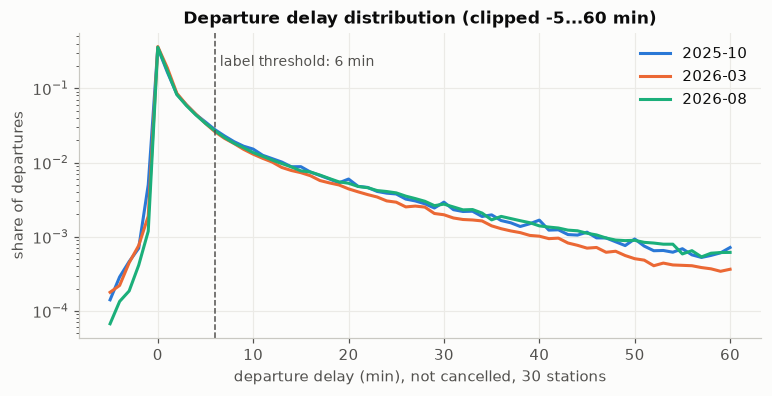

In [6]:
CLIP_LO, CLIP_HI = -5, 60
fig, ax = plt.subplots(figsize=(8, 3.6))
not_cancelled = d[~d.cancelled]
for color, (month, rows) in zip(MONTH_COLORS, not_cancelled.groupby("m"), strict=True):
    counts = rows[rows.delay.between(CLIP_LO, CLIP_HI)].groupby("delay").n.sum()
    ax.plot(counts.index, counts / counts.sum(), color=color, label=month)
ax.axvline(LATE_MIN, color=INK_2, linestyle="--", linewidth=1)
ax.text(LATE_MIN + 0.5, 0.2, "label threshold: 6 min", color=INK_2, fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("departure delay (min), not cancelled, 30 stations")
ax.set_ylabel("share of departures")
ax.set_title(f"Departure delay distribution (clipped {CLIP_LO}...{CLIP_HI} min)")
ax.legend(frameon=False)
plt.show()

In [7]:
q("""
select departure_is_canceled as cancelled, count(*) as n,
       round(avg(delay_in_min), 2) as mean_delay,
       round(avg((delay_in_min >= 6)::int), 3) as share_ge6_if_labelled
from sel group by 1
""")

,cancelled,n,mean_delay,share_ge6_if_labelled
0,True,49902,11.44,0.291
1,False,1213306,5.86,0.249


Cancelled departures still carry a delay value in HF (the last known change) → they must **not** be labelled;
`is_late = null` for them (ADR 0001). Delays ≥ 2 h are rare (≈ 0.2 %); the maximum is ~24 h
(day-shifted services). They stay in silver — the label is unaffected (≥ 6 either way). Negative delays
(early departures, < 1 %) count as not late.

## 4. Late rate by hour, weekday and train type (30 selected stations)

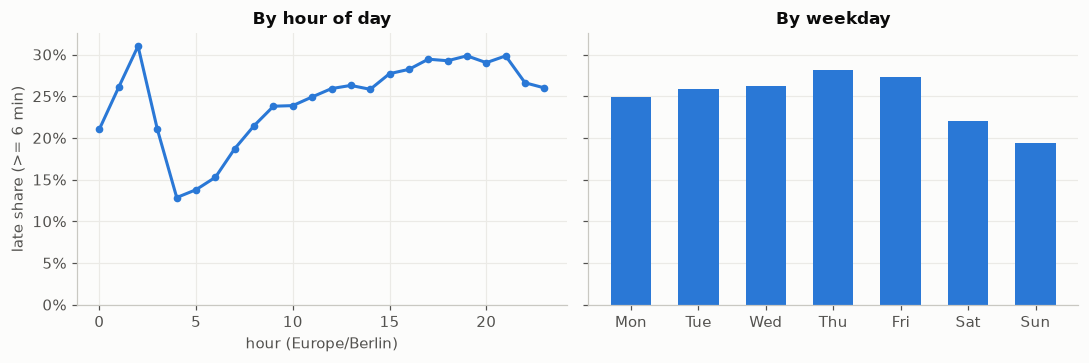

In [8]:
by_time = q("""
select hour(departure_planned_time) as hour_local,
       isodow(departure_planned_time) - 1 as weekday,
       sum((delay_in_min >= 6)::int) as late, count(*) as n
from sel where not departure_is_canceled group by all
""")
by_hour = by_time.groupby("hour_local")[["late", "n"]].sum()
by_day = by_time.groupby("weekday")[["late", "n"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
axes[0].plot(by_hour.index, by_hour.late / by_hour.n, color=BLUE, marker="o", markersize=4)
axes[0].set_xlabel("hour (Europe/Berlin)")
axes[0].set_ylabel("late share (>= 6 min)")
axes[0].set_title("By hour of day")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(days, by_day.late / by_day.n, color=BLUE, width=0.6)
axes[1].set_title("By weekday")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

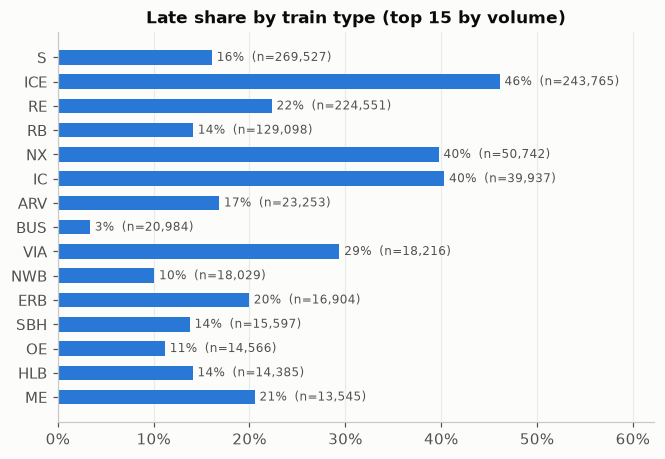

84 distinct train_type values; top 15 cover 88.1% of departures


In [9]:
tt = q("""
select upper(train_type) as train_type, count(*) as n,
       avg((delay_in_min >= 6)::int) filter (where not departure_is_canceled) as late,
       avg(departure_is_canceled::int) as cancelled
from sel group by 1 order by n desc
""")
top = tt.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(top.train_type, top.late, color=BLUE, height=0.6)
for y, (late, n) in enumerate(zip(top.late, top.n, strict=True)):
    ax.text(late + 0.005, y, f"{late:.0%}  (n={n:,})", va="center", fontsize=8, color=INK_2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlim(0, top.late.max() * 1.35)
ax.set_title("Late share by train type (top 15 by volume)")
ax.grid(axis="y", visible=False)
plt.show()
share_top = tt.n.head(15).sum() / tt.n.sum()
print(f"{len(tt)} distinct train_type values; top 15 cover {share_top:.1%} of departures")

Long-distance trains (ICE ≈ 46 %, IC ≈ 40 %) are late about 3× as often as S-Bahn (≈ 16 %). `train_type`
is the operator category (`tl@c`), so regional trains also appear under operator codes (VIA, HLB, ME, erx,
ag, …) and casing is inconsistent → silver upper-cases it; grouping into ICE/IC/EC/RE/RB/S/other is a
Phase 3 feature decision.

## 5. Cardinality of line and destination (feature planning)

In [10]:
q("""
select m,
       count(distinct upper(train_type) || coalesce(line_number, '')) as line_keys,
       count(distinct final_destination_station) as destinations
from sel group by m order by m
""")

,m,line_keys,destinations
0,2025-10,361,875
1,2026-03,421,882
2,2026-08,432,816


In [11]:
levels = q("""
select final_destination_station as dest, count(*) as n from sel group by 1 order by n desc
""")
for k in (50, 100, 500):
    kept = levels.n >= k
    covered = levels.n[kept].sum() / levels.n.sum()
    print(f"destinations with >= {k:>3} rows: {kept.sum():>5}  covering {covered:.1%}")

destinations with >=  50 rows:   714  covering 99.5%
destinations with >= 100 rows:   614  covering 99.0%
destinations with >= 500 rows:   399  covering 94.7%


~360–430 line keys and ~820–880 destinations per month (≈ 400 destinations cover 95 % of rows)
→ rare-level grouping to `OTHER` with a `min_count` (computed on the train split only) is needed,
as planned in architecture §4.

## 6. DST behaviour (timestamps are naive Europe/Berlin)

In [12]:
q("""
select cast(departure_planned_time as date) as day,
       hour(departure_planned_time) as hour_local, count(*) as n
from sel
where cast(departure_planned_time as date)
        in ('2025-10-19', '2025-10-26', '2026-03-22', '2026-03-29')
  and hour(departure_planned_time) between 1 and 4
group by all
""").pivot(index="hour_local", columns="day", values="n")

day,2025-10-19,2025-10-26,2026-03-22,2026-03-29
hour_local,,,,
1,205.0,191.0,163.0,142.0
2,142.0,146.0,119.0,NaN
3,117.0,121.0,105.0,124.0
4,140.0,129.0,152.0,138.0


In [13]:
# Same comparison on all 131 stations of the old scope (incl. Berlin/Hamburg S-Bahn night service).
q("""
select hour(departure_planned_time) as hour_local,
       count(*) filter (where cast(departure_planned_time as date) = '2025-10-19')
         as sun_2025_10_19,
       count(*) filter (where cast(departure_planned_time as date) = '2025-10-26')
         as sun_2025_10_26_dst_end
from dep where m = '2025-10' and hour(departure_planned_time) between 1 and 3
group by 1 order by 1
""")

,hour_local,sun_2025_10_19,sun_2025_10_26_dst_end
0,1,682,699
1,2,525,730
2,3,478,506


- **2025-10-26** (clocks back): across all 131 stations, hour 02 has **1.39×** the volume of the previous
  Sunday (730 vs 525) → the repeated hour is in the data with identical naive timestamps. At the 30 main-line
  EVAs the effect is tiny (146 vs 142 rows). Stop order inside a ride can disambiguate almost none of these
  rows, so `ambiguous="infer"` is not reliable on a flat frame → **ambiguous times become `NaT`, are dropped
  and counted** (≈ 150 rows/year for our stations).
- **2026-03-29** (clocks forward): hour 02 has no rows, as expected (`nonexistent` → `NaT`, drop + count).
- HF timestamps are therefore **Europe/Berlin local time without offset**.

## 7. Coverage over time (collection gaps)

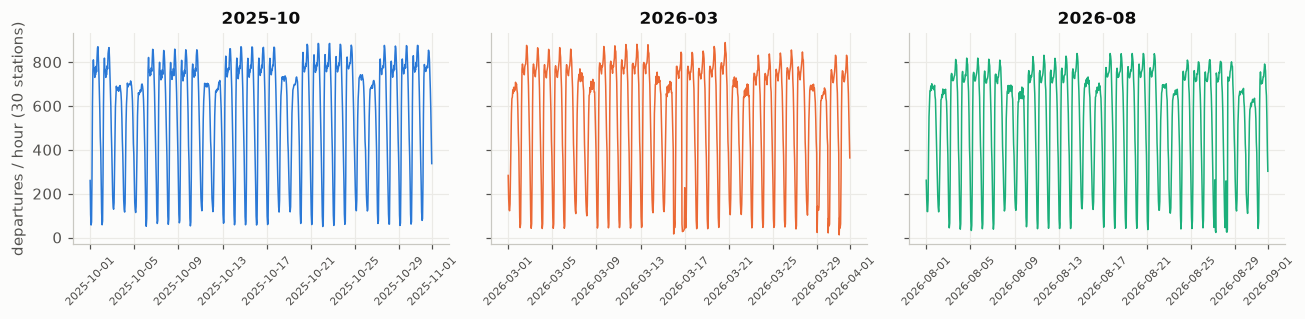

In [14]:
hourly = q("""
select date_trunc('hour', departure_planned_time) as hr, count(*) as n
from sel group by 1 order by 1
""")
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
months = ["2025-10", "2026-03", "2026-08"]
for ax, color, month in zip(axes, MONTH_COLORS, months, strict=True):
    rows = hourly[hourly.hr.dt.strftime("%Y-%m") == month]
    ax.plot(rows.hr, rows.n, color=color, linewidth=1)
    ax.set_title(month)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
axes[0].set_ylabel("departures / hour (30 stations)")
plt.tight_layout()
plt.show()

In [15]:
# Daytime hours (06-21 local) below a quarter of that hour's median volume = collection gap.
DAY_START, DAY_END, GAP_RATIO = 6, 21, 0.25
hourly["hour"] = hourly.hr.dt.hour
median_n = hourly.groupby("hour").n.transform("median")
hourly[hourly.hour.between(DAY_START, DAY_END) & (hourly.n < GAP_RATIO * median_n)]

,hr,n,hour
747,2026-02-28 11:00:00,1,11
748,2026-02-28 13:00:00,1,13
1128,2026-03-16 18:00:00,61,18
1129,2026-03-16 19:00:00,27,19
1130,2026-03-16 20:00:00,31,20
1131,2026-03-16 21:00:00,30,21
2125,2026-08-27 06:00:00,23,6
2149,2026-08-28 06:00:00,24,6
2150,2026-08-28 07:00:00,35,7


Gaps are **collection outages**, not "no trains" (e.g. 2026-03-16 18–21 h, 2026-08-27/28 early morning).
They must not be read as on-time departures; the ETL quality report should flag low-volume hours.
Month files also overlap at the edges (a file contains a few rows planned in the neighbouring month)
→ silver partitions by planned **UTC date** and dedupes on `event_id` across files.

## 8. Station selection (→ `configs/stations.yaml`)

In [16]:
per_station = q("""
select s.eva, s.name, s.state, sel.m, count(*) as n,
       count(distinct cast(departure_planned_time as date)) as days,
       avg((delay_in_min >= 6)::int) filter (where not departure_is_canceled) as late
from sel join stations_df s using (eva) group by all
""")
per_station.pivot_table(
    index=["eva", "name", "state"], columns="m", values=["n", "days", "late"]
).round(3)

days                    late                        n                  
m                                  2025-10 2026-03 2026-08 2025-10 2026-03 2026-08  2025-10  2026-03  2026-08
eva     name                 state                                                                           
8000013 Augsburg Hbf         BY       31.0    32.0    32.0   0.265   0.198   0.228  12764.0  12431.0  12906.0
8000050 Bremen Hbf           HB       32.0    31.0    32.0   0.215   0.147   0.193  11775.0  12250.0  12462.0
8000080 Dortmund Hbf         NW       31.0    32.0    32.0   0.274   0.222   0.289  19611.0  20091.0  16568.0
8000085 Düsseldorf Hbf       NW       32.0    31.0    32.0   0.280   0.289   0.307  32631.0  30410.0  28273.0
8000086 Duisburg Hbf         NW       32.0    32.0    32.0   0.381   0.364   0.429  21798.0  22222.0  19904.0
8000096 Stuttgart Hbf        BW       31.0    32.0    31.0   0.294   0.226   0.157  14603.0  13015.0  18507.0
8000098 Essen Hbf            NW       32.0    32.0    32.0   0.356   0.294   0.319  19390.0  25359.0  22113.0
8000105 Frankfurt (Main) Hbf HE       32.0    32.0    31.0   0.257   0.287   0.269  21164.0  18053.0  20002.0
8000115 Fulda                HE       31.0    32.0    32.0   0.400   0.308   0.390   6997.0   6659.0   7198.0
8000152 Hannover Hbf         NI       31.0    31.0    31.0   0.308   0.210   0.273  22089.0  19603.0  20197.0
8000191 Karlsruhe Hbf        BW       31.0    31.0    32.0   0.190   0.164   0.167  12338.0  12094.0  12674.0
8000199 Kiel Hbf             SH       31.0    31.0    31.0   0.032   0.037   0.042   5060.0   5386.0   5535.0
8000207 Köln Hbf             NW       32.0    32.0    31.0   0.356   0.293   0.324  36409.0  34796.0  33473.0
8000240 Mainz Hbf            RP       31.0    31.0    31.0   0.307   0.310   0.291  13168.0   8029.0  10294.0
8000244 Mannheim Hbf         BW       32.0    31.0    32.0   0.270   0.267   0.302  17044.0  16903.0  17464.0
8000260 Würzburg Hbf         BY       32.0    31.0    31.0   0.302   0.215   0.249   8799.0   8883.0   8565.0
8000261 München Hbf          BY       31.0    31.0    31.0   0.189   0.135   0.165   9138.0   9879.0   9553.0
8000263 Münster (Westf) Hbf  NW       31.0    31.0    32.0   0.346   0.216   0.313  11824.0  11316.0  10825.0
8000284 Nürnberg Hbf         BY       32.0    31.0    32.0   0.173   0.126   0.190  21195.0  21108.0  19312.0
8000323 Saarbrücken Hbf      SL       31.0    31.0    31.0   0.100   0.087   0.124   7173.0   7094.0   6384.0
8002549 Hamburg Hbf          HH       32.0    31.0    31.0   0.270   0.189   0.229  14161.0   9555.0   7829.0
8003200 Kassel-Wilhelmshöhe  HE       32.0    31.0    32.0   0.339   0.291   0.325  12902.0  11513.0  10760.0
8010085 Dresden Hbf          SN       31.0    31.0    31.0   0.096   0.136   0.186  11187.0   9409.0   9013.0
8010101 Erfurt Hbf           TH       32.0    31.0    32.0   0.191   0.215   0.354  10508.0  10818.0  10339.0
8010159 Halle (Saale) Hbf    ST       31.0    31.0    31.0   0.099   0.146   0.159  11226.0  13758.0  13281.0
8010205 Leipzig Hbf          SN       31.0    32.0    32.0   0.170   0.151   0.235   9291.0   8753.0   8752.0
8010224 Magdeburg Hbf        ST       31.0    31.0    32.0   0.205   0.293   0.215   8250.0   8536.0   8503.0
8010304 Rostock Hbf          MV       31.0    31.0    31.0   0.024   0.020   0.045   5114.0   6667.0   7908.0
8012666 Potsdam Hbf          BB       31.0    31.0    31.0   0.104   0.090   0.068   5615.0   4516.0   6130.0
8098160 Berlin Hauptbahnhof  BE       31.0    31.0    32.0   0.292   0.197   0.346  19241.0  22518.0  14395.0

In [17]:
q("""
select m, ltrim(eva, '0') as eva, any_value(xml_station_name) as xml_name,
       upper(train_type) as train_type, count(*) as n
from raw
where departure_planned_time is not null
  and ltrim(eva, '0') in ('8011160', '8098160', '8000096', '8098096')
  and upper(train_type) in ('ICE', 'RE', 'S')
group by all order by 2, 1, 4
""")

,m,eva,xml_name,train_type,n
0,2025-10,8000096,Stuttgart Hbf,ICE,2400
1,2025-10,8000096,Stuttgart Hbf,RE,3998
2,2025-10,8000096,Stuttgart Hbf,S,348
3,2026-03,8000096,Stuttgart Hbf,ICE,3109
4,2026-03,8000096,Stuttgart Hbf,RE,4613
5,2026-03,8000096,Stuttgart Hbf,S,529
6,2026-08,8000096,Stuttgart Hbf,ICE,2192
7,2026-08,8000096,Stuttgart Hbf,RE,3342
8,2026-08,8000096,Stuttgart Hbf,S,7325
9,2025-10,8011160,Berlin Hbf,ICE,3753


- 30 stations, one current non-S-Bahn EVA each (plus `hf_aliases` for merged EVAs), all 16 federal states;
  every station has departures on every collected day in all three months.
- Large stations have several EVAs, and they change. **Berlin Hbf:** until 2026 the upper level was 8011160
  and the lower level 8098160 (both carry ICE/RE); in 2026-03 both are active, by 2026-08 8011160 has 6 rows
  and live it returns an empty timetable, while live 8098160 serves both levels. → `hf_aliases: [8011160]`
  maps the old upper-level history onto 8098160 (applied in the `dep` view above); without it Berlin's
  history would cover only the lower level. Even with the alias, Berlin runs ~460 departures/day in 2026-08 vs ~730 in
  2026-03, steady all month; there is no third Berlin Hbf EVA and trains are not double-listed across the two
  EVAs (< 40 shared rows) → a timetable reduction, not an EVA artefact.
- **Stuttgart Hbf:** in 2026-08 the S-Bahn EVA 8098096 has no rows and S-Bahn trains appear on 8000096
  instead (likely a temporary diversion); live (2026-09-25) S-Bahn is back on 8098096 → no alias. The model
  sees these as `train_type = S`.
- The ETL quality report should flag stations whose volume or train-type mix shifts suddenly.
- Late rates range from ~3 % (Kiel, Rostock) to ~40 % (Duisburg, Fulda): good spread for the model.

## 9. Initial risk thresholds

In [18]:
lookup = q("""
select eva, upper(train_type) as tt, hour(departure_planned_time) as h,
       isodow(departure_planned_time) as wd,
       count(*) as n, avg((delay_in_min >= 6)::int) as late
from sel where not departure_is_canceled
group by all having count(*) >= 30  -- skip tiny cells
""")
risk = pd.cut(
    lookup.late,
    [0, 0.20, 0.45, 1],
    right=False,
    labels=["Low < 0.20", "Medium 0.20-0.45", "High >= 0.45"],
)
(lookup.groupby(risk, observed=False).n.sum() / lookup.n.sum()).to_frame("share of departures")

,share of departures
late,
Low < 0.20,0.473244
Medium 0.20-0.45,0.344014
High >= 0.45,0.182743


Using the baseline-style lookup (station × train type × hour × weekday) as a proxy for calibrated
probabilities, the PRD thresholds **Low < 0.20 / Medium 0.20–0.45 / High ≥ 0.45** put a meaningful share of
departures in every bucket → keep them as the initial values; revisit on the calibrated model output (Phase 4).

## 10. Live API vs HF (id format)

In [19]:
fixtures = ROOT / "tests/fixtures"
plan = (fixtures / "sample_plan.xml").read_text(encoding="utf-8")
fchg = (fixtures / "sample_fchg.xml").read_text(encoding="utf-8")
id_re = re.compile(r'<s id="([^"]+)"')
plan_ids, fchg_ids = set(id_re.findall(plan)), set(id_re.findall(fchg))
hf_id_format = re.compile(r"^-?[0-9]+-[0-9]{10}-[0-9]+$")
print(f"plan stops: {len(plan_ids)}, found in fchg: {len(plan_ids & fchg_ids)}")
print("all live ids match the HF id format:", all(map(hf_id_format.match, plan_ids | fchg_ids)))
print("example:", sorted(plan_ids)[0])
print('cancellations in fchg (cs="c"):', fchg.count('cs="c"'))

plan stops: 19, found in fchg: 19
all live ids match the HF id format: True
example: -1868464253168394146-2609251635-7
cancellations in fchg (cs="c"): 5


Live `s@id` has exactly the HF `id` format; plan and fchg join on it. Planned/changed times in the XML
(`pt`/`ct`, `YYMMDDHHmm`) are Berlin local time as well. A same-day HF ↔ live row match is only possible once
both overlap → reconciliation test in Phase 7.